# 2026-05-04: Testing GPUs (A100 / V100 / H200)

Compare IQ-TREE 3 OpenACC builds on **A100, V100, H200** against CPU baselines (`OMP_10`, `OMP_48`, `VANILA`) for AA + DNA datasets at three alignment lengths (10K, 100K, 1M).

Source logs: `/Users/u7826985/Projects/Nvidia/results/2026_05_04_testing_gpus/`

Run categories present in the dataset:
- `test_cases_*` — standard ML tree search.
- `test_cases_mem_*` / `test_cases_mem_full_*` — full tree search with `-gpumem` budget sweeps (1M only).
- `fixtree_gpumem_*` — fixed input tree (`-te tree_1.full.treefile`) with `-gpumem` budget sweeps (1M only).

Filenames containing `HARDERROR` are runs intended to fail (over-budget VRAM request); `WARN` runs intentionally test the warning path.

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RESULTS_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_05_04_testing_gpus')
OUT_DIR = Path('/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_04_testing_gpus')
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

GPU_COLORS = {'A100': '#76b900', 'V100': '#1f77b4', 'H200': '#d62728'}
EXEC_COLORS = {'OMP_10': '#7f7f7f', 'OMP_48': '#2ca02c', 'VANILA': '#bcbd22',
               'A100': '#76b900', 'V100': '#1f77b4', 'H200': '#d62728'}
LEN_ORDER = [10_000, 100_000, 1_000_000]
GPU_ORDER = ['V100', 'A100', 'H200']

## 1. Parse log files

Walk every `*.log` under the results directory. From the filename we extract category / data type / length / exec type / GPU / model / `-gpumem` setting; from the file body we pull the host, GPU device string, kernel mode, alignment shape, GPU memory required, the best log-likelihood and the wall-clock totals.

In [2]:
FNAME_GPU_RE = re.compile(r'_(A100|V100|H200)_')
FNAME_GPUMEM_RE = re.compile(r'_(1000G|50PCT|30G|16G|8G|2G|CPUMEM50PCT|DEFAULT)_')
FNAME_OMP_RE = re.compile(r'_OMP_?(\d+)')


def classify_filename(path: Path):
    """Return a dict of metadata derived from the filename + parent directory."""
    name = path.name
    parent = path.parent.name        # e.g. 'len_10000'
    grandparent = path.parent.parent.name  # 'AA' or 'DNA'

    length = int(parent.replace('len_', '')) if parent.startswith('len_') else None
    data_type = grandparent if grandparent in ('AA', 'DNA') else None

    if name.startswith('output_fixtree_gpumem_'):
        category = 'fixtree_gpumem'
    elif name.startswith('output_test_cases_mem_full_'):
        category = 'mem_full'
    elif name.startswith('output_test_cases_mem_'):
        category = 'mem'
    elif name.startswith('output_test_cases_'):
        category = 'test_cases'
    else:
        category = 'unknown'

    if '_OPENACC_' in name:
        exec_type = 'OPENACC'
    elif '_VANILA_' in name:
        exec_type = 'VANILA'
    else:
        m = FNAME_OMP_RE.search(name)
        exec_type = f'OMP_{m.group(1)}' if m else None

    m = FNAME_GPU_RE.search(name)
    gpu = m.group(1) if m else None

    m = FNAME_GPUMEM_RE.search(name)
    gpumem = m.group(1) if m else None

    if 'LG-C10' in name:
        model = 'LG+C10'
    elif 'LG-I-G4' in name:
        model = 'LG+I+G4'
    elif 'GTR-I-G4' in name:
        model = 'GTR+I+G4'
    else:
        model = None

    expected_status = None
    if 'HARDERROR' in name:
        expected_status = 'HARDERROR'
    elif '_WARN_' in name:
        expected_status = 'WARN'

    fixed_tree = '_TREEFIXED_' in name or category == 'fixtree_gpumem'

    return {
        'path': str(path),
        'filename': name,
        'category': category,
        'data_type': data_type,
        'length': length,
        'exec_type': exec_type,
        'gpu': gpu,
        'gpumem': gpumem,
        'model': model,
        'fixed_tree': fixed_tree,
        'expected_status': expected_status,
    }

In [3]:
RE_HOST = re.compile(r'^Host:\s+(\S+)')
RE_GPU_DEV = re.compile(r'^GPU:.*?,\s*([^,]+),\s*(\d+)\s*MB')
RE_KERNEL = re.compile(r'^Kernel:\s+(.+?)\s*$')
RE_CMD = re.compile(r'^Command:\s+(.+)')
RE_ALN = re.compile(r'Alignment has (\d+) sequences with (\d+) columns,\s*(\d+) distinct patterns')
RE_GPU_REQ = re.compile(r'NOTE:\s*(\d+)\s*MB GPU memory \(([\d.]+)\s*GB\) is required')
RE_FREE_VRAM = re.compile(r'NOTE:\s*(\d+)\s*MB free VRAM detected')
RE_BEST = re.compile(r'BEST SCORE FOUND\s*:\s*(-?[\d.]+)')
RE_WALL = re.compile(r'Total wall-clock time used:\s*([\d.]+)\s*sec')
RE_CPU = re.compile(r'Total CPU time used:\s*([\d.]+)\s*sec')
RE_TREE_WALL = re.compile(r'Wall-clock time used for tree search:\s*([\d.]+)\s*sec')
RE_MF_WALL = re.compile(r'Wall-clock time for ModelFinder:\s*([\d.]+)\s*seconds')
RE_ITERS = re.compile(r'Total number of iterations:\s*(\d+)')
RE_ERROR = re.compile(r'^ERROR:\s*(.+)')


def parse_log(path: str) -> dict:
    out = {
        'host': None, 'gpu_device': None, 'gpu_total_mb': None, 'kernel': None,
        'command': None, 'sequences': None, 'columns': None, 'patterns': None,
        'gpu_required_mb': None, 'free_vram_mb': None,
        'best_lnl': None, 'wall_total_sec': None, 'cpu_total_sec': None,
        'wall_treesearch_sec': None, 'wall_modelfinder_sec': None, 'iterations': None,
        'error_msg': None, 'completed': False,
    }
    try:
        with open(path, 'r', errors='replace') as f:
            for line in f:
                if out['host'] is None and (m := RE_HOST.match(line)):
                    out['host'] = m.group(1)
                if out['gpu_device'] is None and (m := RE_GPU_DEV.match(line)):
                    out['gpu_device'] = m.group(1).strip()
                    out['gpu_total_mb'] = int(m.group(2))
                if out['kernel'] is None and (m := RE_KERNEL.match(line)):
                    out['kernel'] = m.group(1).strip()
                if out['command'] is None and (m := RE_CMD.match(line)):
                    out['command'] = m.group(1).strip()
                if out['sequences'] is None and (m := RE_ALN.search(line)):
                    out['sequences'] = int(m.group(1))
                    out['columns'] = int(m.group(2))
                    out['patterns'] = int(m.group(3))
                if out['gpu_required_mb'] is None and (m := RE_GPU_REQ.search(line)):
                    out['gpu_required_mb'] = int(m.group(1))
                if out['free_vram_mb'] is None and (m := RE_FREE_VRAM.search(line)):
                    out['free_vram_mb'] = int(m.group(1))
                if (m := RE_BEST.search(line)):
                    out['best_lnl'] = float(m.group(1))
                if (m := RE_WALL.search(line)):
                    out['wall_total_sec'] = float(m.group(1))
                    out['completed'] = True
                if (m := RE_CPU.search(line)):
                    out['cpu_total_sec'] = float(m.group(1))
                if out['wall_treesearch_sec'] is None and (m := RE_TREE_WALL.search(line)):
                    out['wall_treesearch_sec'] = float(m.group(1))
                if out['wall_modelfinder_sec'] is None and (m := RE_MF_WALL.search(line)):
                    out['wall_modelfinder_sec'] = float(m.group(1))
                if (m := RE_ITERS.search(line)):
                    out['iterations'] = int(m.group(1))
                if out['error_msg'] is None and (m := RE_ERROR.match(line)):
                    out['error_msg'] = m.group(1).strip()
    except Exception as e:
        out['error_msg'] = f'parse_failed: {e}'
    return out


def build_dataframe(results_dir: Path) -> pd.DataFrame:
    records = []
    for log in sorted(results_dir.rglob('*.log')):
        if log.name.startswith('output_less_mem_'):
            continue  # handled explicitly below as a CPU fixtree baseline
        meta = classify_filename(log)
        meta.update(parse_log(meta['path']))
        if meta.get('error_msg'):
            if 'gpumem' in meta['error_msg'].lower() or 'VRAM' in meta['error_msg']:
                meta['status'] = 'OOM_ERROR'
            else:
                meta['status'] = 'ERROR'
        elif meta['completed']:
            meta['status'] = 'OK'
        else:
            meta['status'] = 'INCOMPLETE'
        records.append(meta)
    df = pd.DataFrame.from_records(records)
    df['gpu_required_gb'] = df['gpu_required_mb'].astype('Float64') / 1024
    df['wall_total_min'] = df['wall_total_sec'] / 60
    df['cpu_efficiency'] = df['cpu_total_sec'] / df['wall_total_sec']
    return df


df = build_dataframe(RESULTS_DIR)
df['source'] = '2026_05_04_testing_gpus'
print(f'parsed {len(df)} log files from the 2026_05_04 dataset')
df.head(3)

parsed 93 log files from the 2026_05_04 dataset


,path,filename,category,data_type,length,exec_type,gpu,gpumem,model,fixed_tree,...,wall_treesearch_sec,wall_modelfinder_sec,iterations,error_msg,completed,status,gpu_required_gb,wall_total_min,cpu_efficiency,source
0,/Users/u7826985/Projects/Nvidia/results/2026_0...,output_test_cases_AA_LG+I+G4_OMP_10_taxa100_ru...,test_cases,AA,10000,OMP_10,None,None,LG+C10,False,...,8769.673,NaN,102.0,None,True,OK,<NA>,148.323100,9.851823,2026_05_04_testing_gpus
1,/Users/u7826985/Projects/Nvidia/results/2026_0...,output_test_cases_AA_LG+I+G4_OMP_48_taxa100_ru...,test_cases,AA,10000,OMP_48,None,None,LG+C10,False,...,3219.568,NaN,102.0,None,True,OK,<NA>,54.449017,47.188050,2026_05_04_testing_gpus
2,/Users/u7826985/Projects/Nvidia/results/2026_0...,output_test_cases_AA_LG+I+G4_OPENACC_taxa100_r...,test_cases,AA,10000,OPENACC,A100,None,LG+C10,False,...,1330.907,NaN,102.0,None,True,OK,8.985352,22.511767,0.843979,2026_05_04_testing_gpus


## 1b. Backfill CPU baselines from `2026_04_02_kernelrev`

The 2026_05_04 sweep skipped `LG+I+G4` / `GTR+I+G4` CPU runs at 10K/100K/1M sites. We pull rev-kernel CPU runs from the kernelrev archive instead.

**Naming gotcha** — in `2026_04_02_kernelrev`, the file prefix `_kernelrev_` actually marks **fixed-tree** runs (`iqtree3 -te tree_1.full.treefile ...`), while the prefix `_notree_` (despite its name) marks **full-tree-search** runs (no `-te`, 102 NNI iterations, same lnL as the new GPU runs). Since the 2026_05_04 GPU `test_cases_*` runs are full-tree-search, we import only the `notree_*` files for an apples-to-apples comparison. We exclude `kernelnonrev` (different kernel) and any record whose `Command:` line still contains `-te` as a belt-and-braces check. Each imported row is tagged `source = '2026_04_02_kernelrev'`.

In [4]:
KERNELREV_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_04_02_kernelrev')


def import_kernelrev_cpu(results_dir: Path) -> pd.DataFrame:
    """Pull rev-kernel CPU full-tree-search runs from the kernelrev archive."""
    records = []
    for log in sorted(results_dir.rglob('output_fulltest_notree_*.log')):
        name = log.name
        if 'kernelnonrev' in name:
            continue
        if 'OMP_10' in name:
            exec_type = 'OMP_10'
        elif 'OMP_48' in name:
            exec_type = 'OMP_48'
        elif '_VANILA_' in name:
            exec_type = 'VANILA'
        else:
            continue
        parent = log.parent.name
        length = int(parent.replace('len_', '')) if parent.startswith('len_') else None
        data_type = log.parent.parent.name if log.parent.parent.name in ('AA', 'DNA') else None
        if 'LG+I+G4' in name or 'LG-I-G4' in name:
            model = 'LG+I+G4'
        elif 'GTR+I+G4' in name or 'GTR-I-G4' in name:
            model = 'GTR+I+G4'
        else:
            model = None
        rec = {
            'path': str(log), 'filename': name,
            'category': 'test_cases', 'data_type': data_type, 'length': length,
            'exec_type': exec_type, 'gpu': None, 'gpumem': None, 'model': model,
            'fixed_tree': False, 'expected_status': None,
            'source': '2026_04_02_kernelrev',
        }
        rec.update(parse_log(rec['path']))
        cmd = rec.get('command') or ''
        if ' -te ' in cmd or cmd.endswith(' -te'):
            continue  # belt & braces — should never trigger for notree_* files
        if rec.get('error_msg'):
            rec['status'] = 'ERROR'
        elif rec['completed']:
            rec['status'] = 'OK'
        else:
            rec['status'] = 'INCOMPLETE'
        records.append(rec)
    return pd.DataFrame.from_records(records)


extra = import_kernelrev_cpu(KERNELREV_DIR)
print(f'imported {len(extra)} rev-kernel CPU runs ({(extra["status"] == "OK").sum()} OK)')
df = pd.concat([df, extra], ignore_index=True, sort=False)
df['gpu_required_gb'] = df['gpu_required_mb'].astype('Float64') / 1024
df['wall_total_min'] = df['wall_total_sec'] / 60
df['cpu_efficiency'] = df['cpu_total_sec'] / df['wall_total_sec']
df.to_csv(OUT_DIR / 'all_runs.csv', index=False)
extra.groupby(['data_type', 'length', 'exec_type'])['wall_total_sec'].first().unstack('exec_type')

imported 27 rev-kernel CPU runs (26 OK)


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_40003/296465813.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, extra], ignore_index=True, sort=False)


exec_type             OMP_10     OMP_48      VANILA
data_type length                                   
AA        100        181.867     84.859     154.796
          1000       324.945    261.186    1207.186
          10000     1571.782    658.140   11375.955
          100000   12406.564   4704.677         NaN
DNA       100        109.578    277.331      21.313
          1000        47.603    255.767      83.321
          10000      236.592    295.288     898.374
          100000    1429.376    967.299    9299.013
          1000000  29249.823  16874.486  160646.289

In [5]:
# Backfill CPU runtime for the exact `output_fixtree_gpumem_*` workload
# (`-s alignment_1000000.phy -te tree_1.full.treefile -seed 1 -m LG+I+G4 -nt N`).
# The 2026_05_04 sweep's CPU fixtree_gpumem runs are all incomplete, so we pull the
# matching command from `2026_04_28_mem`; only OMP_48 completes the exact command.
FIXTREE_CPU_PATHS = [
    Path('/Users/u7826985/Projects/Nvidia/results/2026_05_04_testing_gpus/AA/len_1000000/'
         'output_less_mem_AA_mi_48_LG+I+G4_VANILA_taxa100_run1_tree_1_1000000_iqtree3_'
         'PHASE_A_1M_B12_VANILA_LG-I-G4_MEMFULL_GROUND_aa.log'),
]

EXPECTED_CMD_TOKENS = ('-s alignment_1000000.phy', '-te tree_1.full.treefile',
                       '-seed 1', '-m LG+I+G4')

fixtree_cpu_records = []
for log in FIXTREE_CPU_PATHS:
    parsed = parse_log(str(log))
    cmd = parsed.get('command') or ''
    missing = [t for t in EXPECTED_CMD_TOKENS if t not in cmd]
    if missing:
        print(f'skipping {log.name}: missing tokens {missing}')
        continue
    if 'OPENACC' in cmd:
        print(f'skipping {log.name}: OPENACC build')
        continue
    if '-nt 48' in cmd:
        exec_type = 'OMP_48'
    elif '-nt 10' in cmd:
        exec_type = 'OMP_10'
    elif '-nt' not in cmd:
        exec_type = 'VANILA'
    else:
        exec_type = None
    rec = {
        'path': str(log), 'filename': log.name,
        'category': 'fixtree_gpumem', 'data_type': 'AA', 'length': 1_000_000,
        'exec_type': exec_type, 'gpu': None, 'gpumem': 'DEFAULT',
        'model': 'LG+I+G4', 'fixed_tree': True, 'expected_status': None,
        'source': '2026_05_04_testing_gpus (cpu fixtree, copied from 2026_04_28_mem)',
    }
    rec.update(parsed)
    rec['status'] = 'OK' if rec.get('completed') else 'INCOMPLETE'
    fixtree_cpu_records.append(rec)

fixtree_cpu_df = pd.DataFrame.from_records(fixtree_cpu_records)
if not fixtree_cpu_df.empty:
    df = pd.concat([df, fixtree_cpu_df], ignore_index=True, sort=False)
    df['gpu_required_gb'] = df['gpu_required_mb'].astype('Float64') / 1024
    df['wall_total_min'] = df['wall_total_sec'] / 60
    df['cpu_efficiency'] = df['cpu_total_sec'] / df['wall_total_sec']
    df.to_csv(OUT_DIR / 'all_runs.csv', index=False)
    ok = df[df['status'] == 'OK'].copy()  # refresh ok view used downstream
if not fixtree_cpu_df.empty:
    fixtree_cpu_df['wall_total_min'] = fixtree_cpu_df['wall_total_sec'] / 60
fixtree_cpu_df[['exec_type', 'gpumem', 'wall_total_sec', 'wall_total_min', 'best_lnl']]

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_40003/1128590487.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, fixtree_cpu_df], ignore_index=True, sort=False)


,exec_type,gpumem,wall_total_sec,wall_total_min,best_lnl
0,OMP_48,DEFAULT,27819.494,463.658233,-7.860520e+07


## 2. Run inventory

How many runs of each kind, and how many of them completed.

In [6]:
inv = (df.groupby(['source', 'data_type', 'length', 'category', 'status'])
         .size()
         .unstack('status', fill_value=0)
         .reset_index()
         .sort_values(['source', 'data_type', 'length', 'category']))
for col in ('OK', 'OOM_ERROR', 'INCOMPLETE', 'ERROR'):
    if col not in inv.columns:
        inv[col] = 0
inv['total'] = inv[['OK', 'OOM_ERROR', 'INCOMPLETE', 'ERROR']].sum(axis=1)
inv

status,source,data_type,length,category,INCOMPLETE,OK,OOM_ERROR,ERROR,total
0,2026_04_02_kernelrev,AA,100,test_cases,0,3,0,0,3
1,2026_04_02_kernelrev,AA,1000,test_cases,0,3,0,0,3
2,2026_04_02_kernelrev,AA,10000,test_cases,0,3,0,0,3
3,2026_04_02_kernelrev,AA,100000,test_cases,1,2,0,0,3
4,2026_04_02_kernelrev,DNA,100,test_cases,0,3,0,0,3
5,2026_04_02_kernelrev,DNA,1000,test_cases,0,3,0,0,3
6,2026_04_02_kernelrev,DNA,10000,test_cases,0,3,0,0,3
7,2026_04_02_kernelrev,DNA,100000,test_cases,0,3,0,0,3
8,2026_04_02_kernelrev,DNA,1000000,test_cases,0,3,0,0,3
9,2026_05_04_testing_gpus,AA,10000,test_cases,0,8,0,0,8


In [7]:
ok = df[df['status'] == 'OK'].copy()
ok[['data_type', 'length', 'category', 'exec_type', 'gpu', 'gpumem',
    'model', 'wall_total_sec', 'wall_total_min', 'cpu_total_sec',
    'cpu_efficiency', 'best_lnl', 'iterations']].sort_values(
    ['data_type', 'length', 'category', 'exec_type', 'gpu']
)

,data_type,length,category,exec_type,gpu,gpumem,model,wall_total_sec,wall_total_min,cpu_total_sec,cpu_efficiency,best_lnl,iterations
93,AA,100,test_cases,OMP_10,None,None,LG+I+G4,181.867,3.031117,1148.457,6.314818,-7.670271e+03,103.0
94,AA,100,test_cases,OMP_48,None,None,LG+I+G4,84.859,1.414317,962.063,11.337195,-7.670271e+03,103.0
95,AA,100,test_cases,VANILA,None,None,LG+I+G4,154.796,2.579933,154.212,0.996227,-7.670271e+03,103.0
96,AA,1000,test_cases,OMP_10,None,None,LG+I+G4,324.945,5.415750,3037.158,9.346683,-7.782396e+04,102.0
97,AA,1000,test_cases,OMP_48,None,None,LG+I+G4,261.186,4.353100,11896.935,45.549666,-7.782396e+04,102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,DNA,1000000,test_cases,OMP_48,None,None,GTR+I+G4,16874.486,281.241433,698178.190,41.374783,-5.920802e+07,102.0
90,DNA,1000000,test_cases,OPENACC,A100,None,GTR+I+G4,4523.878,75.397967,3837.279,0.848228,-5.920802e+07,102.0
91,DNA,1000000,test_cases,OPENACC,H200,None,GTR+I+G4,2673.447,44.557450,2605.771,0.974686,-5.920802e+07,102.0
92,DNA,1000000,test_cases,OPENACC,V100,None,GTR+I+G4,6975.073,116.251217,6864.801,0.984191,-5.920802e+07,102.0


## 3. GPU comparison: A100 vs V100 vs H200 (standard tree search)

Wall-clock for the OPENACC `test_cases_*` runs, grouped by length and model. CPU baselines (`OMP_10`, `OMP_48`) are overlaid for context.

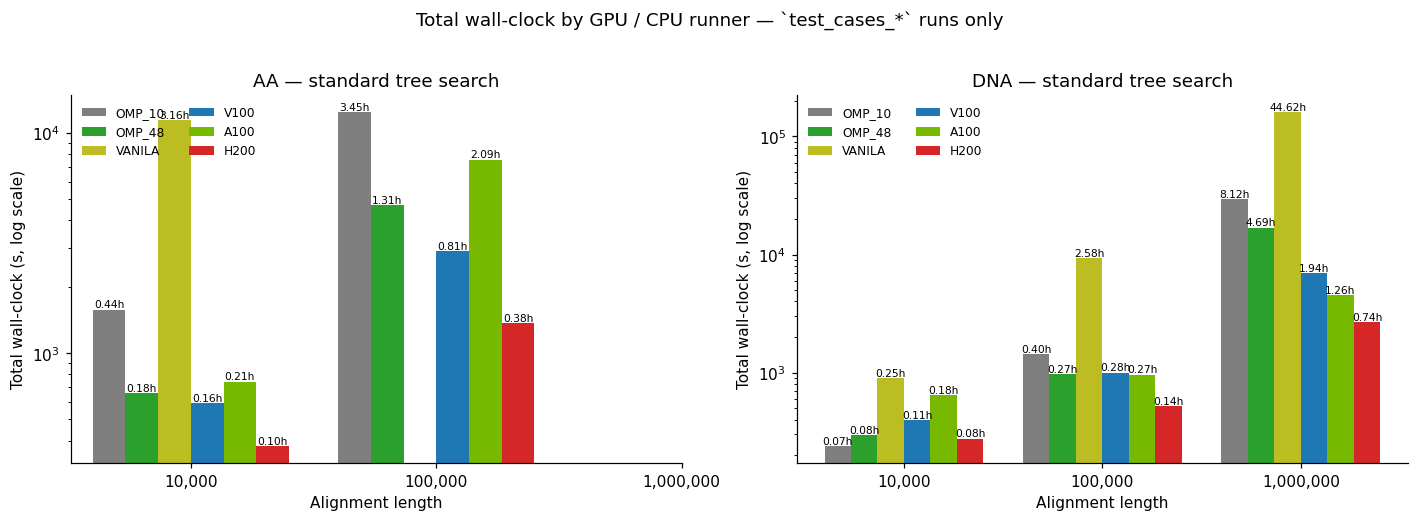

In [8]:
tc = ok[ok['category'] == 'test_cases'].copy()
tc_label = tc.assign(
    runner=tc.apply(lambda r: r['gpu'] if r['gpu'] else r['exec_type'], axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = tc_label[tc_label['data_type'] == dt]
    if sub.empty:
        ax.set_title(f'{dt} (no completed runs)')
        ax.set_axis_off()
        continue
    pivot = (sub.pivot_table(index='length', columns='runner',
                             values='wall_total_sec', aggfunc='min')
                 .reindex(LEN_ORDER))
    runner_order = [c for c in ['OMP_10', 'OMP_48', 'VANILA', 'V100', 'A100', 'H200'] if c in pivot.columns]
    pivot = pivot[runner_order]
    x = np.arange(len(pivot.index))
    width = 0.8 / max(len(runner_order), 1)
    for i, runner in enumerate(runner_order):
        vals = pivot[runner].values
        ax.bar(x + (i - len(runner_order) / 2 + 0.5) * width, vals, width,
               label=runner, color=EXEC_COLORS.get(runner, '#888'))
        for xi, v in zip(x + (i - len(runner_order) / 2 + 0.5) * width, vals):
            if pd.notna(v):
                ax.text(xi, v, f'{v/3600:.2f}h', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(l):,}' for l in pivot.index])
    ax.set_yscale('log')
    ax.set_ylabel('Total wall-clock (s, log scale)')
    ax.set_xlabel('Alignment length')
    ax.set_title(f'{dt} — standard tree search')
    ax.legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle('Total wall-clock by GPU / CPU runner — `test_cases_*` runs only', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig01_walltime_test_cases.png')
plt.show()

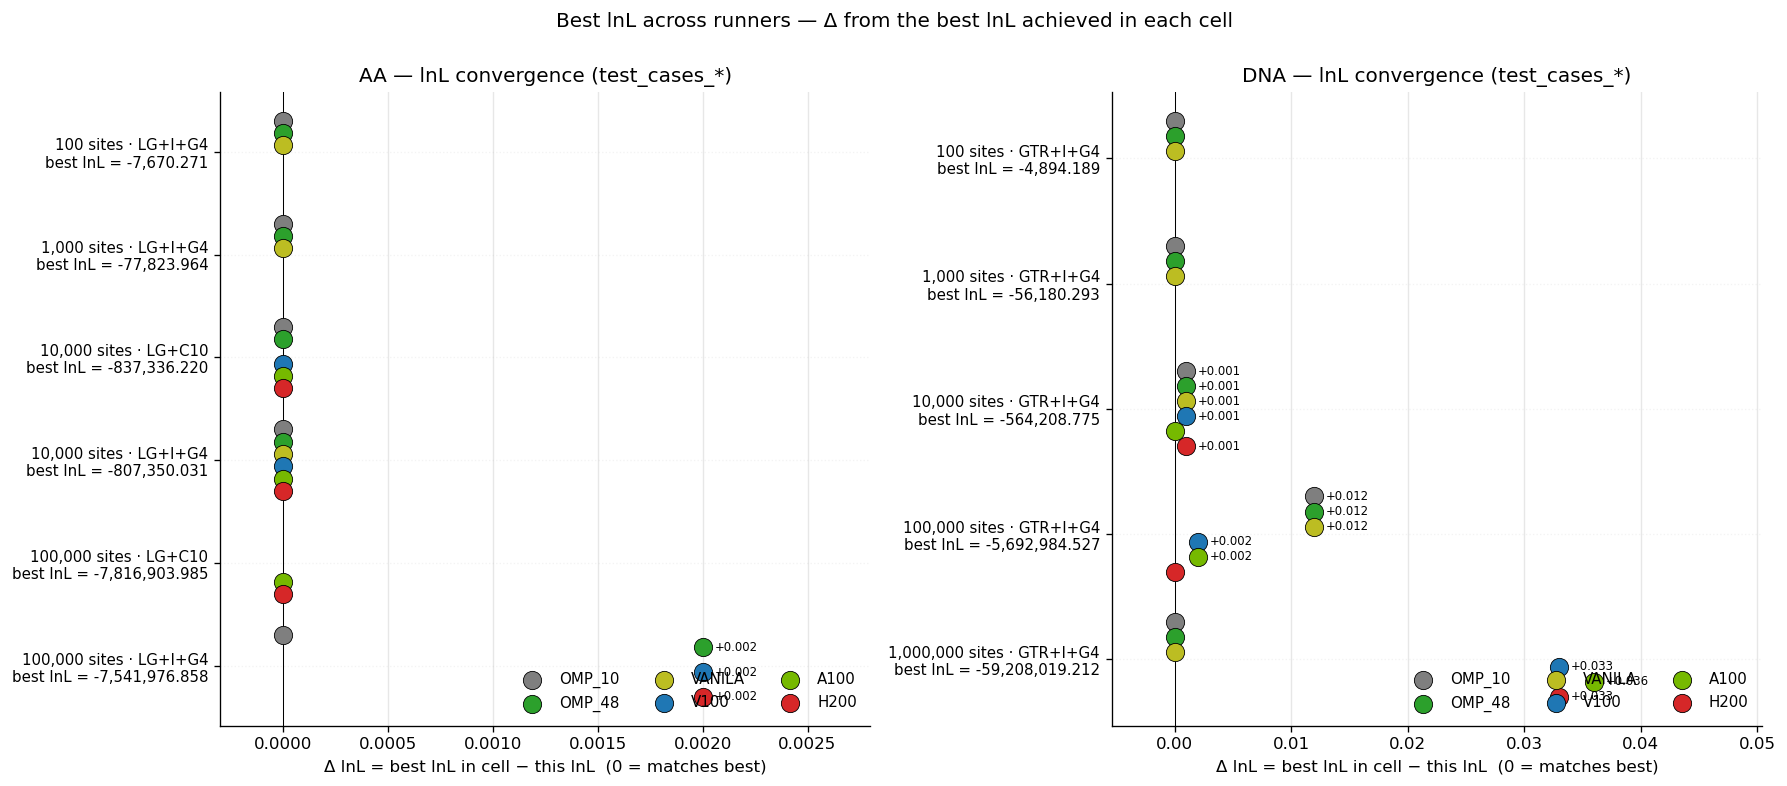

In [9]:
tc_lnl = ok[ok['category'] == 'test_cases'].copy()
tc_lnl = tc_lnl.assign(
    runner=tc_lnl.apply(lambda r: r['gpu'] if r['gpu'] else r['exec_type'], axis=1)
)
tc_lnl['cell_key'] = list(zip(tc_lnl['data_type'], tc_lnl['length'], tc_lnl['model']))
best_per_cell = tc_lnl.groupby('cell_key')['best_lnl'].max()
tc_lnl['lnl_delta'] = tc_lnl['cell_key'].map(best_per_cell) - tc_lnl['best_lnl']
RUNNER_ORDER_PLOT = ['OMP_10', 'OMP_48', 'VANILA', 'V100', 'A100', 'H200']

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=120)
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = tc_lnl[tc_lnl['data_type'] == dt]
    if sub.empty:
        ax.set_title(f'{dt} (no completed runs)')
        ax.set_axis_off()
        continue
    cells = (sub.groupby(['length', 'model'])['lnl_delta']
                .max()
                .reset_index()
                .sort_values(['length', 'model']))
    y_positions = {(row['length'], row['model']): i for i, (_, row) in enumerate(cells.iterrows())}
    cell_labels = [f"{int(L):,} sites · {m}\nbest lnL = {best_per_cell[(dt, L, m)]:,.3f}"
                   for (L, m) in [(r['length'], r['model']) for _, r in cells.iterrows()]]

    n_runners = len(RUNNER_ORDER_PLOT)
    jitter_step = 0.12
    for j, runner in enumerate(RUNNER_ORDER_PLOT):
        s = sub[sub['runner'] == runner]
        if s.empty:
            continue
        offset = (j - (n_runners - 1) / 2) * jitter_step
        ys = [y_positions[(r['length'], r['model'])] + offset for _, r in s.iterrows()]
        xs = s['lnl_delta'].values
        ax.scatter(xs, ys, s=120, color=EXEC_COLORS.get(runner, '#888'),
                   edgecolor='black', lw=0.5, label=runner, zorder=3)
        for xi, yi in zip(xs, ys):
            if pd.notna(xi) and xi > 1e-4:
                ax.annotate(f'+{xi:.3f}', (xi, yi), fontsize=7, color='black',
                            textcoords='offset points', xytext=(7, -2))

    ax.axvline(0, color='black', lw=0.6)
    ax.set_yticks(range(len(cells)))
    ax.set_yticklabels(cell_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Δ lnL = best lnL in cell − this lnL  (0 = matches best)')
    ax.set_title(f'{dt} — lnL convergence (test_cases_*)')
    finite = sub['lnl_delta'].dropna().values
    if finite.size:
        xmax = finite.max() if finite.max() > 0 else 0.005
        ax.set_xlim(-xmax * 0.15, xmax * 1.4)
    ax.legend(fontsize=9, frameon=False, ncol=3, loc='lower right')
    ax.grid(True, axis='x', alpha=0.3)
    ax.grid(True, axis='y', alpha=0.15, ls=':')
fig.suptitle('Best lnL across runners — Δ from the best lnL achieved in each cell',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig09_lnl_test_cases.png')
plt.show()


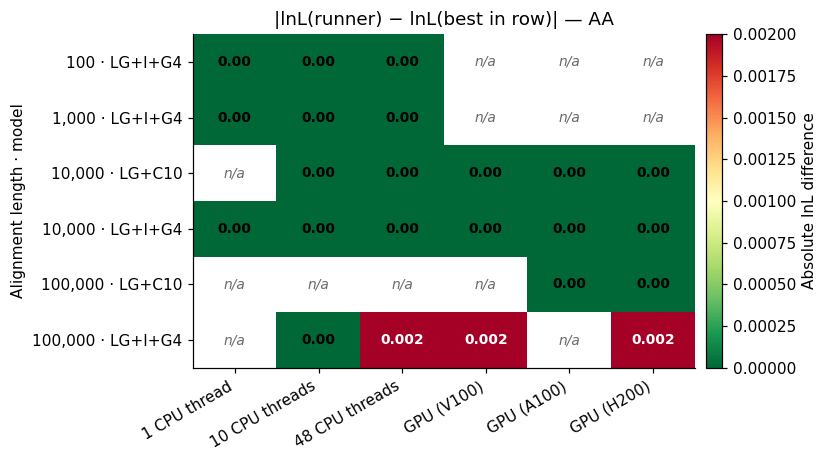

wrote fig10_lnl_diff_heatmap_aa.png


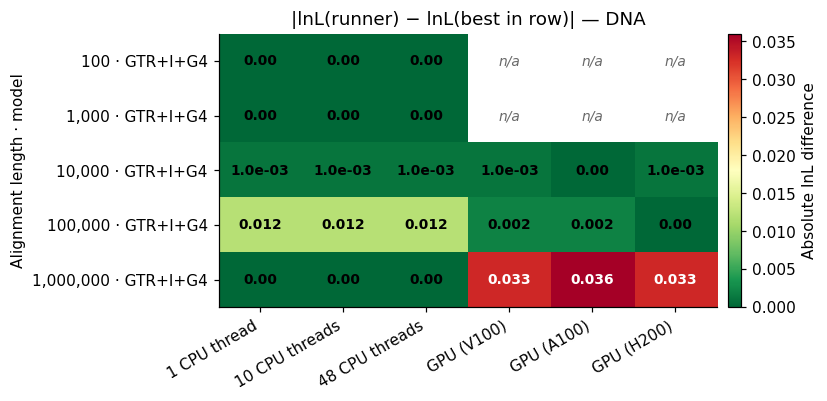

wrote fig10_lnl_diff_heatmap_dna.png


In [10]:
# |lnL - best lnL| heatmap per (data_type), rows = length·model, cols = runner.
# Mirrors the layout of 2026_04_02_kernelrev/aa_lnl_diff_heatmap.png.
RUNNER_COLS = ['VANILA', 'OMP_10', 'OMP_48', 'V100', 'A100', 'H200']
RUNNER_LABELS = {'VANILA': '1 CPU thread', 'OMP_10': '10 CPU threads',
                 'OMP_48': '48 CPU threads', 'V100': 'GPU (V100)',
                 'A100': 'GPU (A100)', 'H200': 'GPU (H200)'}

for dt in ['AA', 'DNA']:
    sub = tc_lnl[tc_lnl['data_type'] == dt]
    if sub.empty:
        continue
    # Pivot: rows = (length, model), cols = runner, value = lnL
    pivot = sub.pivot_table(index=['length', 'model'], columns='runner',
                            values='best_lnl', aggfunc='max')
    cols = [c for c in RUNNER_COLS if c in pivot.columns]
    pivot = pivot[cols].sort_index()
    # Per-row best lnL (least-negative); difference is non-negative
    row_best = pivot.max(axis=1)
    diff = pivot.subtract(row_best, axis=0).abs()

    fig, ax = plt.subplots(figsize=(1.6 + 1.0 * len(cols), 1.0 + 0.55 * len(diff)))
    vmax = max(diff.max().max(), 1e-5)
    im = ax.imshow(diff.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=vmax)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([RUNNER_LABELS.get(c, c) for c in cols], rotation=30, ha='right')
    ax.set_yticks(range(len(diff)))
    ax.set_yticklabels([f'{int(L):,} · {m}' for (L, m) in diff.index])
    ax.set_ylabel('Alignment length · model')
    ax.set_title(f'|lnL(runner) − lnL(best in row)| — {dt}')

    for i in range(diff.shape[0]):
        for j in range(diff.shape[1]):
            v = diff.values[i, j]
            if pd.isna(v):
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=9, color='dimgray', style='italic')
            else:
                if v < 1e-5:
                    txt = '0.00'
                elif v < 1e-3:
                    txt = f'{v:.1e}'
                else:
                    txt = f'{v:.3f}'
                color = 'white' if v > vmax * 0.55 else 'black'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label('Absolute lnL difference')
    fig.tight_layout()
    out_path = OUT_DIR / f'fig10_lnl_diff_heatmap_{dt.lower()}.png'
    fig.savefig(out_path)
    plt.show()
    print(f'wrote {out_path.name}')


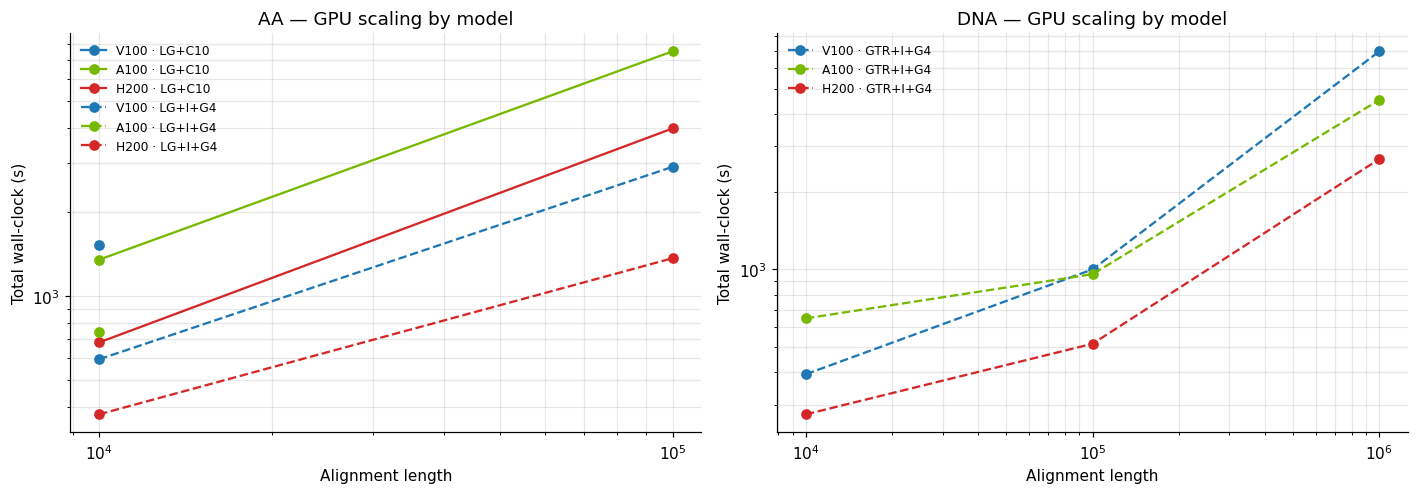

In [11]:
# GPU-only comparison split by model (so LG+C10 vs LG+I+G4 don't get averaged together)
gpu_tc = tc[tc['gpu'].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = gpu_tc[gpu_tc['data_type'] == dt]
    if sub.empty:
        ax.set_title(f'{dt} (no completed GPU runs)')
        ax.set_axis_off()
        continue
    models = sorted(sub['model'].dropna().unique())
    lengths = sorted(sub['length'].dropna().unique())
    for model in models:
        for gpu in GPU_ORDER:
            s = sub[(sub['model'] == model) & (sub['gpu'] == gpu)].sort_values('length')
            if s.empty:
                continue
            ax.plot(s['length'], s['wall_total_sec'], marker='o',
                    label=f'{gpu} · {model}', color=GPU_COLORS[gpu],
                    linestyle='-' if 'C10' in str(model) else '--')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment length')
    ax.set_ylabel('Total wall-clock (s)')
    ax.set_title(f'{dt} — GPU scaling by model')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig02_gpu_scaling.png')
plt.show()

## 4. CPU vs GPU speedup

For each `(data_type, length, model)` cell where both an OMP CPU baseline and an OpenACC GPU run completed, compute `speedup = walltime_cpu / walltime_gpu`.

In [12]:
cpu_rows = tc[tc['exec_type'].astype(str).str.startswith(('OMP_', 'VANILA'))].copy()
gpu_rows = tc[tc['gpu'].notna()].copy()

join = gpu_rows.merge(
    cpu_rows[['data_type', 'length', 'model', 'exec_type', 'wall_total_sec']]
        .rename(columns={'exec_type': 'cpu_runner', 'wall_total_sec': 'cpu_wall_sec'}),
    on=['data_type', 'length', 'model'], how='left')
join['speedup'] = join['cpu_wall_sec'] / join['wall_total_sec']
speedup = (join.dropna(subset=['speedup'])
                [['data_type', 'length', 'model', 'gpu', 'cpu_runner',
                  'cpu_wall_sec', 'wall_total_sec', 'speedup']]
                .sort_values(['data_type', 'length', 'model', 'gpu']))
speedup.to_csv(OUT_DIR / 'speedup_cpu_vs_gpu.csv', index=False)
speedup

,data_type,length,model,gpu,cpu_runner,cpu_wall_sec,wall_total_sec,speedup
0,AA,10000,LG+C10,A100,OMP_10,8899.386,1350.706,6.588692
1,AA,10000,LG+C10,A100,OMP_48,3266.941,1350.706,2.418691
2,AA,10000,LG+C10,H200,OMP_10,8899.386,682.385,13.041591
3,AA,10000,LG+C10,H200,OMP_48,3266.941,682.385,4.787533
4,AA,10000,LG+C10,V100,OMP_10,8899.386,1525.183,5.834963
5,AA,10000,LG+C10,V100,OMP_48,3266.941,1525.183,2.141999
6,AA,10000,LG+I+G4,A100,OMP_10,1571.782,741.859,2.118707
7,AA,10000,LG+I+G4,A100,OMP_48,658.140,741.859,0.887150
8,AA,10000,LG+I+G4,A100,VANILA,11375.955,741.859,15.334390
9,AA,10000,LG+I+G4,H200,OMP_10,1571.782,377.020,4.168962


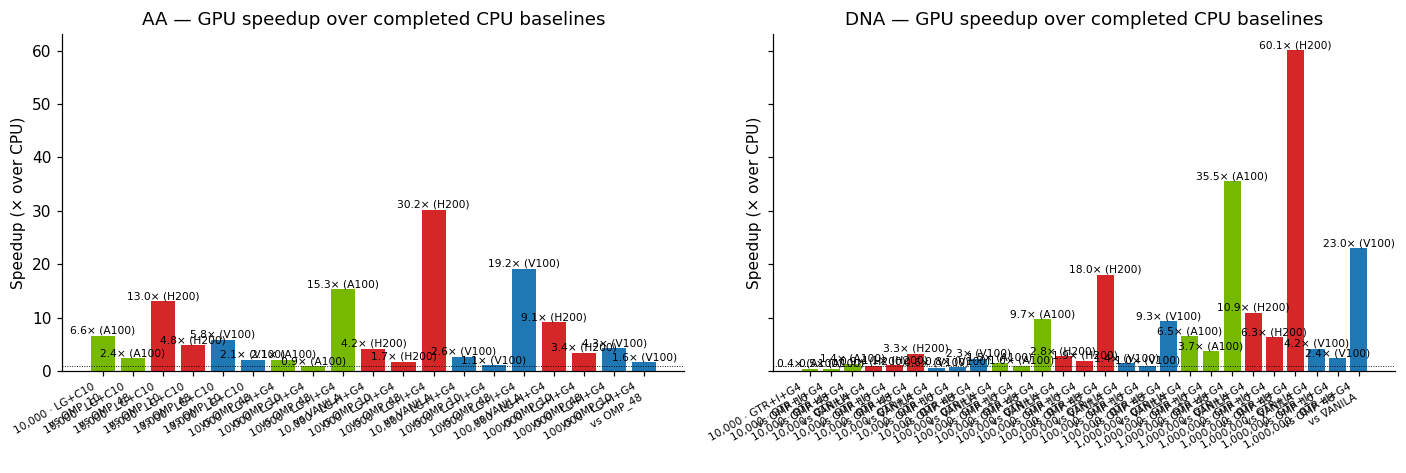

In [13]:
if not speedup.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
    for ax, dt in zip(axes, ['AA', 'DNA']):
        sub = speedup[speedup['data_type'] == dt]
        if sub.empty:
            ax.set_title(f'{dt} (no matched pairs)')
            ax.set_axis_off()
            continue
        labels = sub.apply(
            lambda r: f"{int(r['length']):,} · {r['model']}\nvs {r['cpu_runner']}", axis=1)
        x = np.arange(len(sub))
        bars = ax.bar(x, sub['speedup'], color=[GPU_COLORS.get(g, '#888') for g in sub['gpu']])
        for xi, v, gpu in zip(x, sub['speedup'], sub['gpu']):
            ax.text(xi, v, f'{v:.1f}× ({gpu})', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
        ax.axhline(1.0, color='k', lw=0.6, ls=':')
        ax.set_ylabel('Speedup (× over CPU)')
        ax.set_title(f'{dt} — GPU speedup over completed CPU baselines')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig03_speedup.png')
    plt.show()
else:
    print('No matched CPU/GPU pairs available for speedup chart.')

## 5. GPU memory budget sweep (1M sites)

`mem`, `mem_full`, and `fixtree_gpumem` runs explore `-gpumem` settings on H200 / V100 / A100. The fixed-tree variants isolate the per-iteration likelihood cost; the full-search variants include tree-search overhead.

In [14]:
mem_categories = ['mem', 'mem_full', 'fixtree_gpumem']
mem_df = df[df['category'].isin(mem_categories)].copy()

GPUMEM_ORDER = ['2G', '8G', '16G', '30G', '50PCT', 'DEFAULT', 'CPUMEM50PCT', '1000G']
mem_df['gpumem'] = pd.Categorical(mem_df['gpumem'], categories=GPUMEM_ORDER, ordered=True)

summary = (mem_df
           .groupby(['category', 'gpu', 'gpumem', 'expected_status'], observed=True)
           ['status']
           .value_counts()
           .unstack(fill_value=0)
           .reset_index()
           .sort_values(['category', 'gpu', 'gpumem']))
summary

status,category,gpu,gpumem,expected_status,INCOMPLETE,OOM_ERROR
0,fixtree_gpumem,H200,CPUMEM50PCT,WARN,1,0
1,fixtree_gpumem,H200,1000G,HARDERROR,0,1
2,fixtree_gpumem,V100,CPUMEM50PCT,WARN,0,1
3,fixtree_gpumem,V100,1000G,HARDERROR,0,1
4,mem,A100,1000G,HARDERROR,0,1
5,mem,H200,CPUMEM50PCT,WARN,1,0
6,mem,H200,1000G,HARDERROR,0,1
7,mem,V100,CPUMEM50PCT,WARN,0,1
8,mem,V100,1000G,HARDERROR,0,1
9,mem_full,A100,CPUMEM50PCT,WARN,1,0


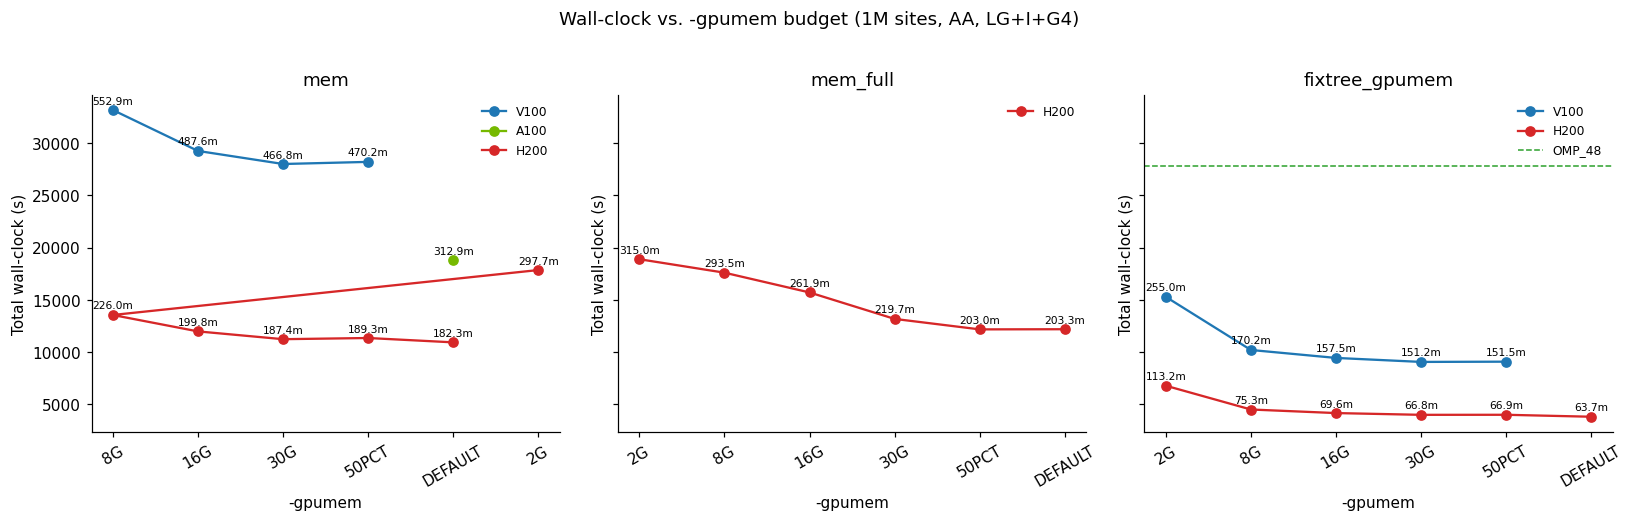

In [15]:
mem_ok = mem_df[mem_df['status'] == 'OK'].copy()
if not mem_ok.empty:
    fig, axes = plt.subplots(1, len(mem_categories), figsize=(15, 4.6), sharey=True)
    if len(mem_categories) == 1:
        axes = [axes]
    for ax, cat in zip(axes, mem_categories):
        sub = mem_ok[mem_ok['category'] == cat]
        ax.set_title(f'{cat}')
        if sub.empty:
            ax.text(0.5, 0.5, 'no completed runs', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
            ax.set_axis_off()
            continue
        runners = []
        for gpu in GPU_ORDER:
            s = sub[sub['gpu'] == gpu].sort_values('gpumem')
            if s.empty:
                continue
            ax.plot(s['gpumem'].astype(str), s['wall_total_sec'], marker='o',
                    label=gpu, color=GPU_COLORS[gpu])
            for xi, v in zip(s['gpumem'].astype(str), s['wall_total_sec']):
                ax.annotate(f'{v/60:.1f}m', (xi, v), fontsize=7,
                            textcoords='offset points', xytext=(0, 4), ha='center')
            runners.append(gpu)
        for runner in ['OMP_10', 'OMP_48', 'VANILA']:
            s = sub[sub['exec_type'] == runner]
            if s.empty or pd.isna(s['wall_total_sec']).all():
                continue
            ax.axhline(s['wall_total_sec'].iloc[0], lw=1.0, color=EXEC_COLORS[runner],
                       ls='--', label=runner)
        ax.set_xlabel('-gpumem')
        ax.set_ylabel('Total wall-clock (s)')
        ax.tick_params(axis='x', rotation=30)
        if runners:
            ax.legend(fontsize=8, frameon=False)
    fig.suptitle('Wall-clock vs. -gpumem budget (1M sites, AA, LG+I+G4)', y=1.02)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig04_gpumem_sweep.png')
    plt.show()
else:
    print('No completed memory-sweep runs.')

## 5b. `fixtree_gpumem` — wall-clock and likelihood detail

All `fixtree_gpumem` runs use the same fixed input tree (`-te tree_1.full.treefile`) and the same model (`LG+I+G4` on AA, 1M sites), so the *only* free knob is `-gpumem`. Wall-clock should drop as the GPU gets more VRAM headroom (less host↔device shuffling); the log-likelihood at convergence should be **identical** across budgets — drift would be a numerical-stability red flag.

In [16]:
fixtree = df[(df['category'] == 'fixtree_gpumem') & (df['status'] == 'OK')].copy()
fixtree['gpumem'] = pd.Categorical(fixtree['gpumem'], categories=GPUMEM_ORDER, ordered=True)
fixtree = fixtree.sort_values(['gpu', 'exec_type', 'gpumem'])
fixtree[['gpu', 'exec_type', 'gpumem', 'wall_total_sec', 'wall_total_min', 'best_lnl', 'gpu_required_gb', 'source']].to_csv(
    OUT_DIR / 'fixtree_gpumem_results.csv', index=False)
fixtree[['gpu', 'exec_type', 'gpumem', 'wall_total_sec', 'wall_total_min', 'best_lnl', 'source']]

,gpu,exec_type,gpumem,wall_total_sec,wall_total_min,best_lnl,source
20,H200,OPENACC,2G,6792.838,113.213967,-7.860520e+07,2026_05_04_testing_gpus
23,H200,OPENACC,8G,4515.710,75.261833,-7.860520e+07,2026_05_04_testing_gpus
19,H200,OPENACC,16G,4174.860,69.581000,-7.860520e+07,2026_05_04_testing_gpus
21,H200,OPENACC,30G,4006.425,66.773750,-7.860520e+07,2026_05_04_testing_gpus
22,H200,OPENACC,50PCT,4011.116,66.851933,-7.860520e+07,2026_05_04_testing_gpus
25,H200,OPENACC,DEFAULT,3823.543,63.725717,-7.860520e+07,2026_05_04_testing_gpus
28,V100,OPENACC,2G,15297.657,254.960950,-7.860520e+07,2026_05_04_testing_gpus
31,V100,OPENACC,8G,10211.561,170.192683,-7.860520e+07,2026_05_04_testing_gpus
27,V100,OPENACC,16G,9451.463,157.524383,-7.860520e+07,2026_05_04_testing_gpus
29,V100,OPENACC,30G,9069.129,151.152150,-7.860520e+07,2026_05_04_testing_gpus


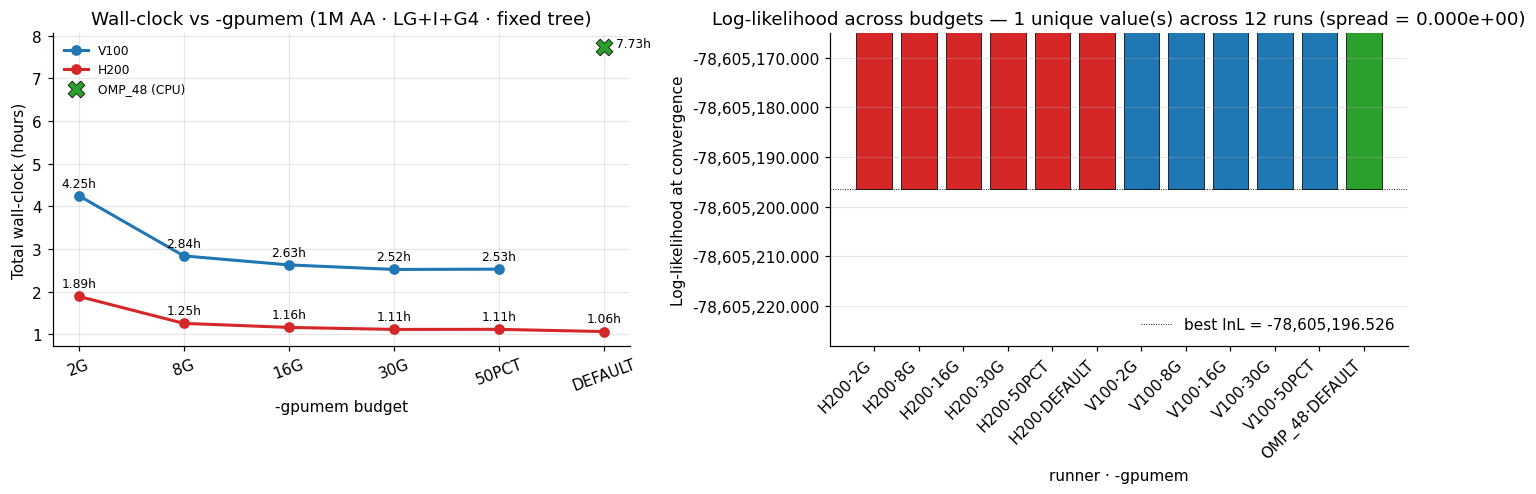

Unique lnL values across 12 fixtree_gpumem runs: 1
Range: [-78,605,196.526, -78,605,196.526]  (spread = 0.000e+00)


In [17]:
if not fixtree.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    ax_w, ax_l = axes

    for gpu in GPU_ORDER:
        s = fixtree[fixtree['gpu'] == gpu]
        if s.empty:
            continue
        x = s['gpumem'].astype(str)
        ax_w.plot(x, s['wall_total_sec'] / 3600, marker='o', lw=2,
                  color=GPU_COLORS[gpu], label=gpu)
        for xi, v in zip(x, s['wall_total_sec']):
            ax_w.annotate(f'{v/3600:.2f}h', (xi, v / 3600), fontsize=8,
                          textcoords='offset points', xytext=(0, 6), ha='center')
    cpu_at_default = fixtree[fixtree['exec_type'].astype(str).str.startswith(('OMP_', 'VANILA'))]
    for _, row in cpu_at_default.iterrows():
        ax_w.scatter('DEFAULT', row['wall_total_sec'] / 3600, marker='X', s=120,
                     color=EXEC_COLORS.get(row['exec_type'], '#888'),
                     edgecolor='black', lw=0.5,
                     label=f"{row['exec_type']} (CPU)", zorder=5)
        ax_w.annotate(f"{row['wall_total_sec']/3600:.2f}h",
                      ('DEFAULT', row['wall_total_sec'] / 3600),
                      fontsize=8, textcoords='offset points', xytext=(8, 0))
    ax_w.set_xlabel('-gpumem budget')
    ax_w.set_ylabel('Total wall-clock (hours)')
    ax_w.set_title('Wall-clock vs -gpumem (1M AA · LG+I+G4 · fixed tree)')
    ax_w.legend(frameon=False, fontsize=8)
    ax_w.grid(True, alpha=0.3)
    ax_w.tick_params(axis='x', rotation=20)

    runner_x = []
    runner_colors = []
    for _, r in fixtree.iterrows():
        if r['gpu']:
            runner_x.append(f"{r['gpu']}·{r['gpumem']}")
            runner_colors.append(GPU_COLORS[r['gpu']])
        else:
            runner_x.append(f"{r['exec_type']}·{r['gpumem']}")
            runner_colors.append(EXEC_COLORS.get(r['exec_type'], '#888'))
    ax_l.bar(runner_x, fixtree['best_lnl'], color=runner_colors, edgecolor='black', lw=0.5)
    lnl_min, lnl_max = fixtree['best_lnl'].min(), fixtree['best_lnl'].max()
    spread = lnl_max - lnl_min
    pad = max(spread, abs(lnl_max) * 1e-7)
    ax_l.set_ylim(lnl_min - 4 * pad, lnl_max + 4 * pad)
    ax_l.axhline(lnl_max, color='black', lw=0.6, ls=':', label=f'best lnL = {lnl_max:,.3f}')
    ax_l.set_ylabel('Log-likelihood at convergence')
    ax_l.set_xlabel('runner · -gpumem')
    n_unique = fixtree['best_lnl'].round(3).nunique()
    ax_l.set_title(f'Log-likelihood across budgets — {n_unique} unique value(s) across {len(fixtree)} runs (spread = {spread:.3e})')
    ax_l.tick_params(axis='x', rotation=45)
    for tick in ax_l.get_xticklabels():
        tick.set_horizontalalignment('right')
    ax_l.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.3f}'))
    ax_l.grid(True, axis='y', alpha=0.3)
    ax_l.legend(frameon=False, loc='lower right')

    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig07_fixtree_gpumem_detail.png')
    plt.show()
    print(f"Unique lnL values across {len(fixtree)} fixtree_gpumem runs: {n_unique}")
    print(f"Range: [{lnl_min:,.3f}, {lnl_max:,.3f}]  (spread = {spread:.3e})")
else:
    print('No completed fixtree_gpumem runs to plot.')

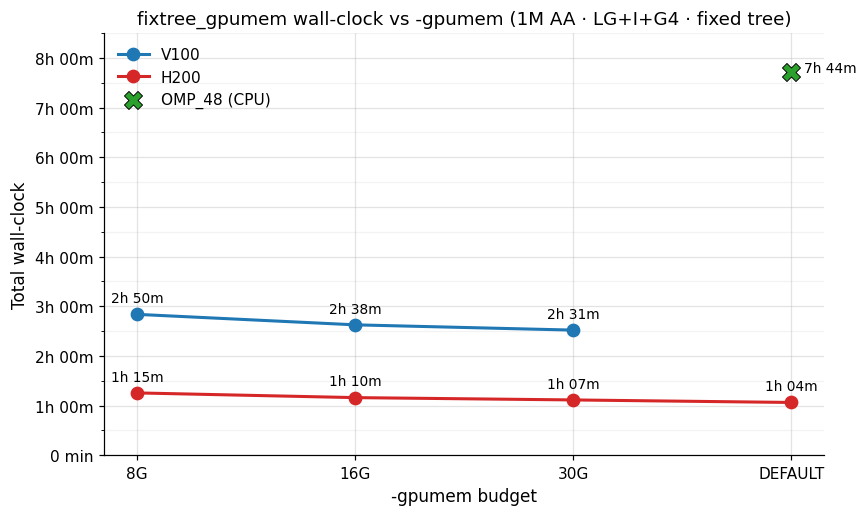

In [18]:
EXCLUDE_BUDGETS = {'2G', '50PCT'}
fixtree_subset = fixtree[~fixtree['gpumem'].astype(str).isin(EXCLUDE_BUDGETS)]
if not fixtree_subset.empty:
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for gpu in GPU_ORDER:
        s = fixtree_subset[fixtree_subset['gpu'] == gpu]
        if s.empty:
            continue
        x = s['gpumem'].astype(str)
        hours = s['wall_total_sec'] / 3600
        ax.plot(x, hours, marker='o', lw=2, ms=8,
                color=GPU_COLORS[gpu], label=gpu)
        for xi, h in zip(x, hours):
            hh = int(h); mm = int(round((h - hh) * 60))
            label = f'{hh}h {mm:02d}m' if hh else f'{mm} min'
            ax.annotate(label, (xi, h), fontsize=9,
                        textcoords='offset points', xytext=(0, 8), ha='center')
    cpu_rows = fixtree_subset[fixtree_subset['exec_type'].astype(str).str.startswith(('OMP_', 'VANILA'))]
    for _, r in cpu_rows.iterrows():
        h = r['wall_total_sec'] / 3600
        ax.scatter('DEFAULT', h, marker='X', s=140,
                   color=EXEC_COLORS.get(r['exec_type'], '#888'),
                   edgecolor='black', lw=0.6,
                   label=f"{r['exec_type']} (CPU)", zorder=5)
        hh = int(h); mm = int(round((h - hh) * 60))
        label = f'{hh}h {mm:02d}m' if hh else f'{mm} min'
        ax.annotate(label, ('DEFAULT', h), fontsize=9,
                    textcoords='offset points', xytext=(8, 0))
    ax.set_xlabel('-gpumem budget', fontsize=11)
    ax.set_ylabel('Total wall-clock', fontsize=11)
    ax.set_title('fixtree_gpumem wall-clock vs -gpumem (1M AA · LG+I+G4 · fixed tree)')

    all_h = pd.concat([fixtree_subset['wall_total_sec'] / 3600,
                       cpu_rows['wall_total_sec'] / 3600 if not cpu_rows.empty else pd.Series(dtype=float)])
    ymax_h = all_h.max()
    top = np.ceil((ymax_h + 0.5) * 2) / 2
    ax.set_ylim(0, top)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1.0 if top > 5 else 0.5))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5 if top > 5 else 0.25))
    def hm(v, _):
        hh = int(v); mm = int(round((v - hh) * 60))
        return f'{hh}h {mm:02d}m' if hh else f'{mm} min'
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(hm))
    ax.legend(frameon=False, fontsize=10)
    ax.grid(True, which='major', alpha=0.35)
    ax.grid(True, which='minor', alpha=0.15)
    ax.tick_params(axis='x', rotation=0)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig08_fixtree_gpumem_walltime.png')
    plt.show()

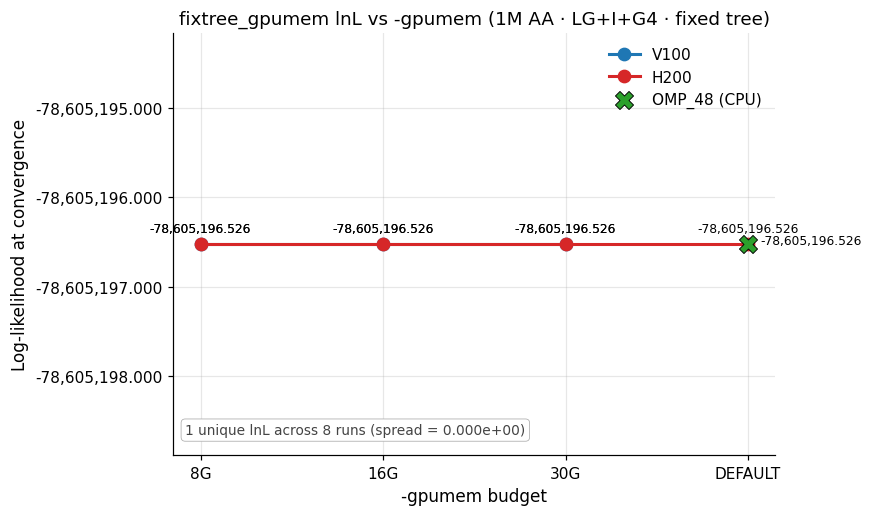

In [19]:
EXCLUDE_BUDGETS = {'2G', '50PCT'}
fixtree_subset = fixtree[~fixtree['gpumem'].astype(str).isin(EXCLUDE_BUDGETS)]
if not fixtree_subset.empty:
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for gpu in GPU_ORDER:
        s = fixtree_subset[fixtree_subset['gpu'] == gpu]
        if s.empty:
            continue
        x = s['gpumem'].astype(str)
        ax.plot(x, s['best_lnl'], marker='o', lw=2, ms=8,
                color=GPU_COLORS[gpu], label=gpu)
        for xi, v in zip(x, s['best_lnl']):
            ax.annotate(f'{v:,.3f}', (xi, v), fontsize=8,
                        textcoords='offset points', xytext=(0, 8), ha='center')
    cpu_rows = fixtree_subset[fixtree_subset['exec_type'].astype(str).str.startswith(('OMP_', 'VANILA'))]
    for _, r in cpu_rows.iterrows():
        ax.scatter('DEFAULT', r['best_lnl'], marker='X', s=140,
                   color=EXEC_COLORS.get(r['exec_type'], '#888'),
                   edgecolor='black', lw=0.6,
                   label=f"{r['exec_type']} (CPU)", zorder=5)
        ax.annotate(f"{r['best_lnl']:,.3f}", ('DEFAULT', r['best_lnl']),
                    fontsize=8, textcoords='offset points', xytext=(8, 0))
    ax.set_xlabel('-gpumem budget', fontsize=11)
    ax.set_ylabel('Log-likelihood at convergence', fontsize=11)
    ax.set_title('fixtree_gpumem lnL vs -gpumem (1M AA · LG+I+G4 · fixed tree)')

    lnl_min = fixtree_subset['best_lnl'].min()
    lnl_max = fixtree_subset['best_lnl'].max()
    spread = lnl_max - lnl_min
    pad = max(spread, abs(lnl_max) * 5e-9)
    ax.set_ylim(lnl_min - 6 * pad, lnl_max + 6 * pad)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.3f}'))
    n_unique = fixtree_subset['best_lnl'].round(3).nunique()
    ax.text(0.02, 0.05,
            f'{n_unique} unique lnL across {len(fixtree_subset)} runs (spread = {spread:.3e})',
            transform=ax.transAxes, fontsize=9, color='#444',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', lw=0.5))
    ax.legend(frameon=False, fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig11_fixtree_gpumem_lnl.png')
    plt.show()

## 6. GPU memory required vs available

How close did the runs get to filling each GPU's VRAM? Useful for sanity-checking what the OOM line is on each card.

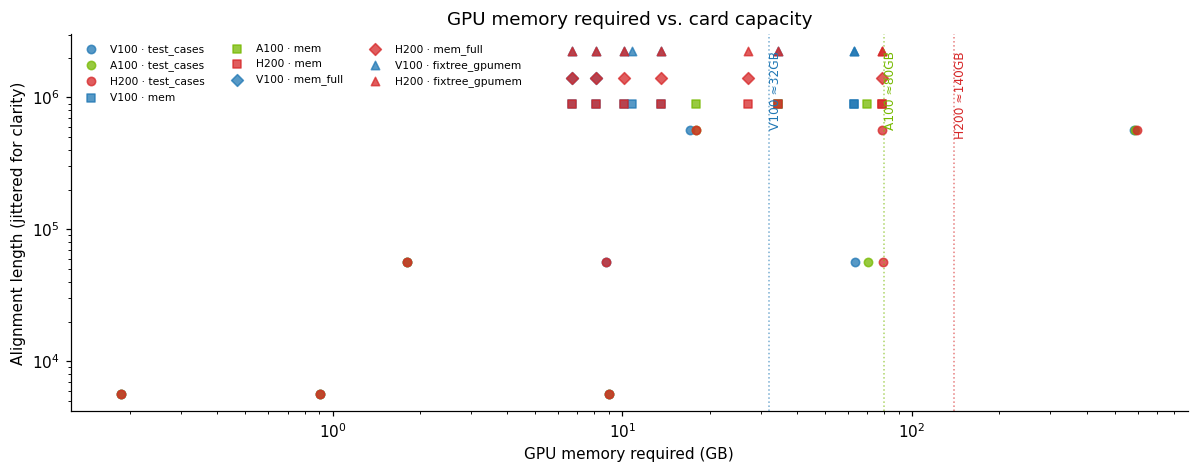

In [20]:
vram = df[df['gpu'].notna() & df['gpu_required_mb'].notna()].copy()
if not vram.empty:
    vram['gpu_total_gb'] = vram['gpu_total_mb'] / 1024
    fig, ax = plt.subplots(figsize=(11, 4.4))
    cat_offset = {'test_cases': -0.25, 'mem': -0.05, 'mem_full': 0.15, 'fixtree_gpumem': 0.35}
    for cat, off in cat_offset.items():
        sub = vram[vram['category'] == cat]
        if sub.empty:
            continue
        for gpu in GPU_ORDER:
            ss = sub[sub['gpu'] == gpu]
            if ss.empty:
                continue
            ax.scatter(ss['gpu_required_gb'],
                       ss['length'].astype(float) * 10 ** off,
                       color=GPU_COLORS[gpu], s=30, alpha=0.75,
                       marker={'test_cases':'o', 'mem':'s', 'mem_full':'D', 'fixtree_gpumem':'^'}[cat],
                       label=f'{gpu} · {cat}')
    for gpu, gb in [('V100', 32), ('A100', 80), ('H200', 140)]:
        ax.axvline(gb, color=GPU_COLORS[gpu], ls=':', lw=1, alpha=0.6)
        ax.text(gb, ax.get_ylim()[1] * 0.95, f'{gpu} ≈{gb}GB', color=GPU_COLORS[gpu],
                rotation=90, va='top', fontsize=8)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('GPU memory required (GB)')
    ax.set_ylabel('Alignment length (jittered for clarity)')
    ax.set_title('GPU memory required vs. card capacity')
    ax.legend(fontsize=7, frameon=False, ncol=3, loc='upper left')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig05_vram_required.png')
    plt.show()
else:
    print('No GPU-memory data to plot.')

## 7. Log-likelihood consistency

For matching `(data_type, length, model)` cells, the GPU and CPU runs should converge to essentially the same `BEST SCORE FOUND` (small deltas come from non-deterministic NNI ordering, not numerics).

In [21]:
lnl = (ok[ok['category'] == 'test_cases']
       .pivot_table(index=['data_type', 'length', 'model'],
                    columns=ok[ok['category'] == 'test_cases']
                            .apply(lambda r: r['gpu'] if r['gpu'] else r['exec_type'], axis=1),
                    values='best_lnl', aggfunc='first'))
lnl

A100          H200        OMP_10  \
data_type length  model                                                
AA        100     LG+I+G4            NaN           NaN -7.670271e+03   
          1000    LG+I+G4            NaN           NaN -7.782396e+04   
          10000   LG+C10   -8.373362e+05 -8.373362e+05 -8.373362e+05   
                  LG+I+G4  -8.073500e+05 -8.073500e+05 -8.073500e+05   
          100000  LG+C10   -7.816904e+06 -7.816904e+06           NaN   
                  LG+I+G4            NaN -7.541977e+06 -7.541977e+06   
DNA       100     GTR+I+G4           NaN           NaN -4.894189e+03   
          1000    GTR+I+G4           NaN           NaN -5.618029e+04   
          10000   GTR+I+G4 -5.642088e+05 -5.642088e+05 -5.642088e+05   
          100000  GTR+I+G4 -5.692985e+06 -5.692985e+06 -5.692985e+06   
          1000000 GTR+I+G4 -5.920802e+07 -5.920802e+07 -5.920802e+07   

                                  OMP_48          V100        VANILA  
data_type length  model                                               
AA        100     LG+I+G4  -7.670271e+03           NaN -7.670271e+03  
          1000    LG+I+G4  -7.782396e+04           NaN -7.782396e+04  
          10000   LG+C10   -8.373362e+05 -8.373362e+05           NaN  
                  LG+I+G4  -8.073500e+05 -8.073500e+05 -8.073500e+05  
          100000  LG+C10             NaN           NaN           NaN  
                  LG+I+G4  -7.541977e+06 -7.541977e+06           NaN  
DNA       100     GTR+I+G4 -4.894189e+03           NaN -4.894189e+03  
          1000    GTR+I+G4 -5.618029e+04           NaN -5.618029e+04  
          10000   GTR+I+G4 -5.642088e+05 -5.642088e+05 -5.642088e+05  
          100000  GTR+I+G4 -5.692985e+06 -5.692985e+06 -5.692985e+06  
          1000000 GTR+I+G4 -5.920802e+07 -5.920802e+07 -5.920802e+07

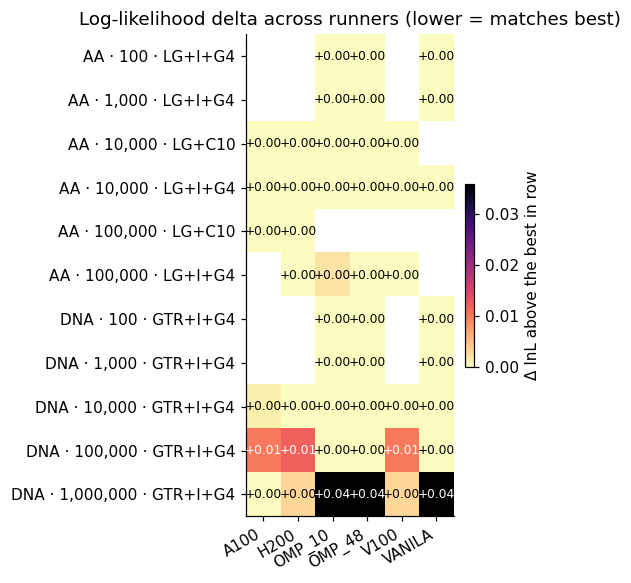

In [22]:
if not lnl.empty:
    delta = lnl.subtract(lnl.min(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(min(1 + 0.7 * len(delta.columns), 12), 1 + 0.4 * len(delta)))
    im = ax.imshow(delta.values, cmap='magma_r', aspect='auto')
    ax.set_xticks(range(len(delta.columns)))
    ax.set_xticklabels(delta.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(delta.index)))
    ax.set_yticklabels([f"{dt} · {int(L):,} · {m}" for dt, L, m in delta.index])
    for i in range(delta.shape[0]):
        for j in range(delta.shape[1]):
            v = delta.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                        fontsize=8, color='white' if v > delta.values[~np.isnan(delta.values)].mean() else 'black')
    cbar = plt.colorbar(im, ax=ax, fraction=0.04)
    cbar.set_label('Δ lnL above the best in row')
    ax.set_title('Log-likelihood delta across runners (lower = matches best)')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'fig06_lnl_delta.png')
    plt.show()

## 8. Failed / incomplete runs

Quick reference: which runs hit OOM, errored, or timed out without writing a final wall-clock line.

In [23]:
failed = df[df['status'] != 'OK'][
    ['data_type', 'length', 'category', 'exec_type', 'gpu', 'gpumem',
     'model', 'expected_status', 'status', 'error_msg', 'filename']
].sort_values(['data_type', 'length', 'category', 'gpu', 'gpumem'])
failed

,data_type,length,category,exec_type,gpu,gpumem,model,expected_status,status,error_msg,filename
12,AA,100000,test_cases,OPENACC,V100,None,LG+C10,None,OOM_ERROR,ERROR: Your GPU VRAM is below minimum requirem...,output_test_cases_AA_LG+I+G4_OPENACC_taxa100_r...
8,AA,100000,test_cases,OMP_10,None,None,LG+C10,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_OMP_10_taxa100_ru...
9,AA,100000,test_cases,OMP_48,None,None,LG+C10,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_OMP_48_taxa100_ru...
15,AA,100000,test_cases,VANILA,None,None,LG+C10,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_VANILA_taxa100_ru...
104,AA,100000,test_cases,VANILA,None,None,LG+I+G4,None,INCOMPLETE,None,output_fulltest_notree_AA_LG+I+G4_VANILA_taxa1...
18,AA,1000000,fixtree_gpumem,OPENACC,H200,1000G,LG+I+G4,HARDERROR,OOM_ERROR,ERROR: -gpumem requested 1000 GB but only 139....,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...
24,AA,1000000,fixtree_gpumem,OPENACC,H200,CPUMEM50PCT,LG+I+G4,WARN,INCOMPLETE,None,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...
26,AA,1000000,fixtree_gpumem,OPENACC,V100,1000G,LG+I+G4,HARDERROR,OOM_ERROR,ERROR: -gpumem requested 1000 GB but only 31.4...,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...
32,AA,1000000,fixtree_gpumem,OPENACC,V100,CPUMEM50PCT,LG+I+G4,WARN,OOM_ERROR,ERROR: Your GPU VRAM is below minimum requirem...,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...
33,AA,1000000,fixtree_gpumem,OPENACC,V100,DEFAULT,LG+I+G4,None,OOM_ERROR,ERROR: Your GPU VRAM is below minimum requirem...,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...


In [24]:
expected_oom = failed[(failed['expected_status'] == 'HARDERROR') & (failed['status'] == 'OOM_ERROR')]
unexpected = failed[failed['expected_status'].isna() | (failed['status'] != 'OOM_ERROR') & (failed['expected_status'] == 'HARDERROR')]
print(f'Expected HARDERROR runs that errored as designed: {len(expected_oom)}')
print(f'Unexpected failures (incomplete or unexpectedly errored): {len(unexpected)}')
unexpected[['data_type', 'length', 'category', 'exec_type', 'gpu', 'gpumem',
            'status', 'expected_status', 'filename']]

Expected HARDERROR runs that errored as designed: 5
Unexpected failures (incomplete or unexpectedly errored): 33


,data_type,length,category,exec_type,gpu,gpumem,status,expected_status,filename
12,AA,100000,test_cases,OPENACC,V100,None,OOM_ERROR,None,output_test_cases_AA_LG+I+G4_OPENACC_taxa100_r...
8,AA,100000,test_cases,OMP_10,None,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_OMP_10_taxa100_ru...
9,AA,100000,test_cases,OMP_48,None,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_OMP_48_taxa100_ru...
15,AA,100000,test_cases,VANILA,None,None,INCOMPLETE,None,output_test_cases_AA_LG+I+G4_VANILA_taxa100_ru...
104,AA,100000,test_cases,VANILA,None,None,INCOMPLETE,None,output_fulltest_notree_AA_LG+I+G4_VANILA_taxa1...
33,AA,1000000,fixtree_gpumem,OPENACC,V100,DEFAULT,OOM_ERROR,None,output_fixtree_gpumem_AA_LG+I+G4_OPENACC_taxa1...
16,AA,1000000,fixtree_gpumem,VANILA,None,None,INCOMPLETE,None,output_fixtree_gpumem_AA_LG+I+G4_OMP_10_taxa10...
17,AA,1000000,fixtree_gpumem,VANILA,None,None,INCOMPLETE,None,output_fixtree_gpumem_AA_LG+I+G4_OMP_48_taxa10...
34,AA,1000000,fixtree_gpumem,VANILA,None,None,INCOMPLETE,None,output_fixtree_gpumem_AA_LG+I+G4_VANILA_taxa10...
47,AA,1000000,mem,OPENACC,A100,50PCT,INCOMPLETE,None,output_test_cases_mem_AA_LG+I+G4_OPENACC_taxa1...


## 9. Summary table

Persisted alongside the figures so the headline numbers are easy to lift into reports.

In [25]:
summary_table = (ok[ok['category'] == 'test_cases']
                 .assign(runner=lambda d: d.apply(lambda r: r['gpu'] if r['gpu'] else r['exec_type'], axis=1))
                 .pivot_table(index=['data_type', 'length', 'model'],
                              columns='runner',
                              values='wall_total_sec',
                              aggfunc='min')
                 .round(1))
summary_table.to_csv(OUT_DIR / 'walltime_summary.csv')
summary_table

runner                        A100    H200   OMP_10   OMP_48    V100    VANILA
data_type length  model                                                       
AA        100     LG+I+G4      NaN     NaN    181.9     84.9     NaN     154.8
          1000    LG+I+G4      NaN     NaN    324.9    261.2     NaN    1207.2
          10000   LG+C10    1350.7   682.4   8899.4   3266.9  1525.2       NaN
                  LG+I+G4    741.9   377.0   1571.8    658.1   593.8   11376.0
          100000  LG+C10    7538.2  3988.9      NaN      NaN     NaN       NaN
                  LG+I+G4      NaN  1367.1  12406.6   4704.7  2905.5       NaN
DNA       100     GTR+I+G4     NaN     NaN    109.6    277.3     NaN      21.3
          1000    GTR+I+G4     NaN     NaN     47.6    255.8     NaN      83.3
          10000   GTR+I+G4   647.0   275.3    236.6    295.3   393.4     898.4
          100000  GTR+I+G4   958.8   516.1   1429.4    967.3  1000.5    9299.0
          1000000 GTR+I+G4  4523.9  2673.4  29249.8  16874.5  6975.1  160646.3